## Chapter 16 of *R for Data Science* (2e, 2023)

In [1]:
%load_ext autoreload
%autoreload 2

import hea
from hea import data

### 16.2

In [2]:
x1 = ["Dec", "Apr", "Jan", "Mar"]
x2 = ["Dec", "Apr", "Jam", "Mar"]

In [3]:
hea.R.sort(x1)

array(['Apr', 'Dec', 'Jan', 'Mar'], dtype='<U3')

In [4]:
from hea.R import factor, levels

month_levels = [
  "Jan", "Feb", "Mar", "Apr", "May", "Jun",
  "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]
y1 = factor(x1, levels = month_levels)
y1

""
enum
"""Dec"""
"""Apr"""
"""Jan"""
"""Mar"""


In [5]:
hea.R.sort(y1)

""
enum
"""Jan"""
"""Mar"""
"""Apr"""
"""Dec"""


In [6]:
y2 = factor(x2, levels = month_levels)
y2

# use factor(x2, levels= month_levels, strict=True) to achieve the result of `forcats::fct()`

""
enum
"""Dec"""
"""Apr"""
null
"""Mar"""


In [7]:
# factor(x2, levels= month_levels, strict=True)

In [8]:
factor(x1)

""
enum
"""Dec"""
"""Apr"""
"""Jan"""
"""Mar"""


In [9]:
factor(x1, strict=True)

""
enum
"""Dec"""
"""Apr"""
"""Jan"""
"""Mar"""


### 16.3

In [10]:
gss_cat = data("gss_cat")

In [11]:
gss_cat.count("race")

race,n
enum,u32
"""White""",16395
"""Black""",3129
"""Other""",1959


### 16.4

In [12]:
from hea import col, n
relig_summary = (
    gss_cat
        .group_by("relig")
        .summarize(
            tvhours = col("tvhours").mean(),
            n = n()
        )
)

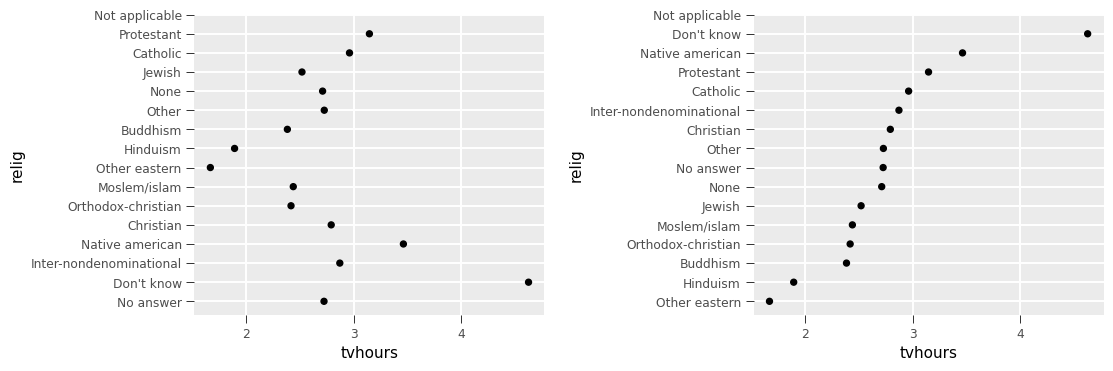

<Figure size 1098.25x351 with 0 Axes>

In [13]:
from hea import fct_reorder
p1 = relig_summary.ggplot(x = "tvhours", y = "relig").geom_point()
p2 = relig_summary.ggplot(x = "tvhours", y = fct_reorder("relig", "tvhours")).geom_point()
p1 | p2

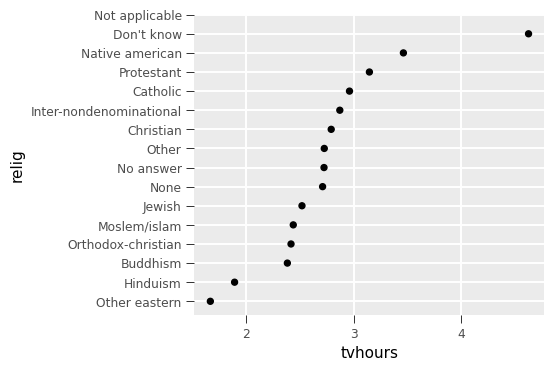

In [14]:
(
    relig_summary
        .mutate(relig = fct_reorder("relig", "tvhours"))
        .ggplot(x = "tvhours", y = "relig")
        .geom_point()  
)

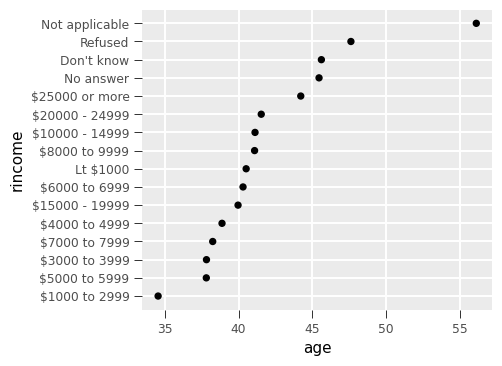

In [15]:
rincome_summary = (
    gss_cat
        .group_by("rincome")
        .summarize(
            age = col("age").mean(),
            n = n()
        )

)

rincome_summary.ggplot(x = "age", y = fct_reorder("rincome", "age")).geom_point()

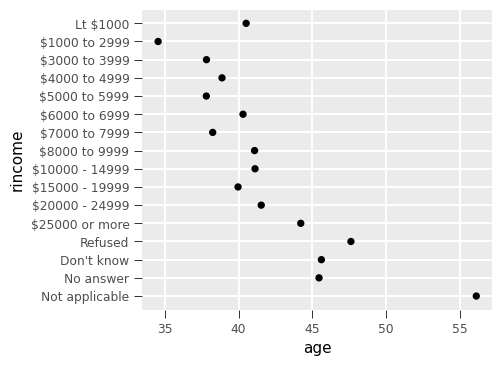

In [16]:
from hea import fct_relevel
rincome_summary.ggplot(x = "age", y = fct_relevel("rincome", "Not applicable")).geom_point()

In [17]:
by_age = (
    gss_cat
        .filter(~col("age").is_null())
        .count("age", "marital")
        .group_by("age")
        .mutate(
            prop = col("n") / col("n").sum()
        )
)

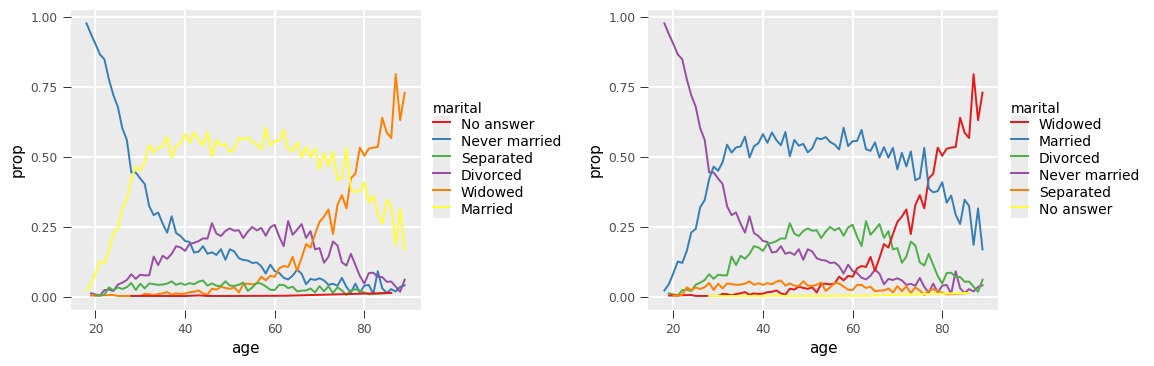

<Figure size 1135.75x351 with 0 Axes>

In [18]:
from hea import fct_reorder2
p1 = (
    by_age
        .ggplot(x="age", y="prop", color="marital")
        .geom_line(linewidth=1)
        .scale_color_brewer(palette="Set1")
)

p2 = (
    by_age
        .ggplot(x = "age", y = "prop", color = fct_reorder2("marital", "age", "prop"))
        .geom_line(linewidth=1)
        .scale_color_brewer(palette="Set1")
        .labs(color="marital")        
)

p1 | p2

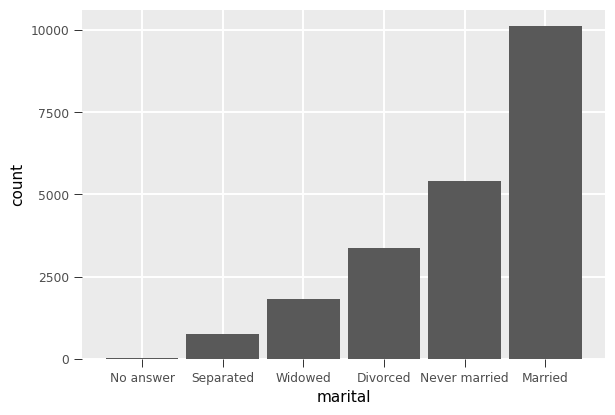

In [19]:
from hea import fct_infreq, fct_rev
(
    gss_cat
        .mutate(marital = fct_rev(fct_infreq("marital")))
        .ggplot(x="marital")
        .geom_bar()
).show(figsize=(6,4))


### 16.5

In [20]:
gss_cat.count("partyid")

partyid,n
enum,u32
"""Ind,near rep""",1791
"""Not str republican""",3032
"""Independent""",4119
"""Not str democrat""",3690
"""Strong democrat""",3490
"""Ind,near dem""",2499
"""Strong republican""",2314
"""Other party""",393
"""No answer""",154


In [21]:
from hea import fct_recode
(
    gss_cat
     .mutate(
            partyid=fct_recode("partyid", **{
                    "Republican, strong":    "Strong republican",
                    "Republican, weak":      "Not str republican",
                    "Independent, near rep": "Ind,near rep",
                    "Independent, near dem": "Ind,near dem",
                    "Democrat, weak":        "Not str democrat",
                    "Democrat, strong":      "Strong democrat",
                })
    ).count("partyid")
)

partyid,n
enum,u32
"""Independent, near rep""",1791
"""Republican, weak""",3032
"""Independent""",4119
"""Democrat, weak""",3690
"""Democrat, strong""",3490
"""Independent, near dem""",2499
"""Republican, strong""",2314
"""Other party""",393
"""No answer""",154


In [22]:
(
    gss_cat
        .mutate(
            partyid = fct_recode("partyid",**{
                "Republican, strong"    : "Strong republican",
                "Republican, weak"      : "Not str republican",
                "Independent, near rep" : "Ind,near rep",
                "Independent, near dem" : "Ind,near dem",
                "Democrat, weak"        : "Not str democrat",
                "Democrat, strong"      : "Strong democrat",
                "Other"                 : ["No answer", "Don't know", "Other party"],
            })
        ).count("partyid")
)

partyid,n
enum,u32
"""Independent, near rep""",1791
"""Republican, weak""",3032
"""Independent""",4119
"""Democrat, weak""",3690
"""Democrat, strong""",3490
"""Independent, near dem""",2499
"""Republican, strong""",2314
"""Other""",548


In [23]:
from hea import fct_collapse
(
    gss_cat
        .mutate(partyid=fct_collapse("partyid", **{
            "other": ["No answer", "Don't know", "Other party"],
            "rep":   ["Strong republican", "Not str republican"],
            "ind":   ["Ind,near rep", "Independent", "Ind,near dem"],
            "dem":   ["Not str democrat", "Strong democrat"],
        })).count("partyid")
)

partyid,n
enum,u32
"""ind""",8409
"""rep""",5346
"""dem""",7180
"""other""",548


In [24]:
from hea import fct_lump_lowfreq

(
    gss_cat
        .mutate(relig = fct_lump_lowfreq("relig"))
        .count("relig")
)

relig,n
enum,u32
"""Protestant""",10846
"""Other""",10637


In [25]:
from hea import fct_lump_n

(
    gss_cat
        .mutate(relig = fct_lump_n("relig", n = 10))
        .count("relig", sort = True)
)

relig,n
enum,u32
"""Protestant""",10846
"""Catholic""",5124
"""None""",3523
"""Christian""",689
"""Other""",458
"""Jewish""",388
"""Buddhism""",147
"""Inter-nondenominational""",109
"""Moslem/islam""",104


In [26]:
from hea.R import ordered

ordered(("a", "b", "c"))

""
enum
"""a"""
"""b"""
"""c"""
